In [132]:
import pandas as pd
data = pd.read_csv("train.csv")

In [133]:
data.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [134]:
data.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [135]:
data.shape

(891, 12)

In [136]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [137]:
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [138]:
data.describe(include="object")

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,B96 B98,S
freq,1,577,7,4,644


In [139]:
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [140]:
data_copy = data

In [141]:
data_copy = data_copy.dropna(subset="Embarked")

In [142]:
data_copy.isnull().sum()


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

In [143]:
age_mean = data_copy["Age"].mean()
data_copy["Age"] = data_copy["Age"].fillna(age_mean)


/var/folders/3s/z4g_j0r16qb02_v0xs2_8s5c0000gn/T/ipykernel_55951/3443867757.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_copy["Age"] = data_copy["Age"].fillna(age_mean)


In [144]:
data_copy.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

In [145]:
data_copy = data_copy.drop(columns="Cabin")

In [146]:
data_copy.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [147]:
mode = data["Embarked"].mode()[0]

In [148]:
data["Embarked"] = data["Embarked"].fillna(mode)


In [149]:
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

In [150]:
mode = data["Age"].mode()[0]
mode

np.float64(24.0)

In [151]:
min = data["Age"].min()
min

0.42

In [152]:
max = data["Age"].max()
max

80.0

In [153]:
mean = data["Age"].mean()
mean

np.float64(29.69911764705882)

In [154]:
median = data["Age"].median()
median

28.0

In [155]:
mode = data["Age"].mode()
mode

0    24.0
Name: Age, dtype: float64

In [156]:
from scipy.stats import skew, kurtosis

In [157]:
data['Age'].quantile(0.05)

np.float64(4.0)

In [158]:
data['Age'].var()

211.0191247463081

In [159]:
skew(data['Age'].dropna())

np.float64(0.3882898514698657)

In [160]:
kurtosis(data['Age'].dropna())

np.float64(0.16863657224286044)

In [161]:
Sex = {"male":0, "female":1}

In [162]:
data["Sex"] = data["Sex"].map(Sex)
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,S


In [163]:
import seaborn as sb
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
corr_matrix = data.corr(numeric_only = True)
corr_matrix 

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,-0.042939,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,0.543351,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.131900,-0.369226,0.083081,0.018443,-0.549500
Sex,-0.042939,0.543351,-0.131900,1.000000,-0.093254,0.114631,0.245489,0.182333
Age,0.036847,-0.077221,-0.369226,-0.093254,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,0.114631,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,0.245489,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.182333,0.096067,0.159651,0.216225,1.000000


<Axes: >

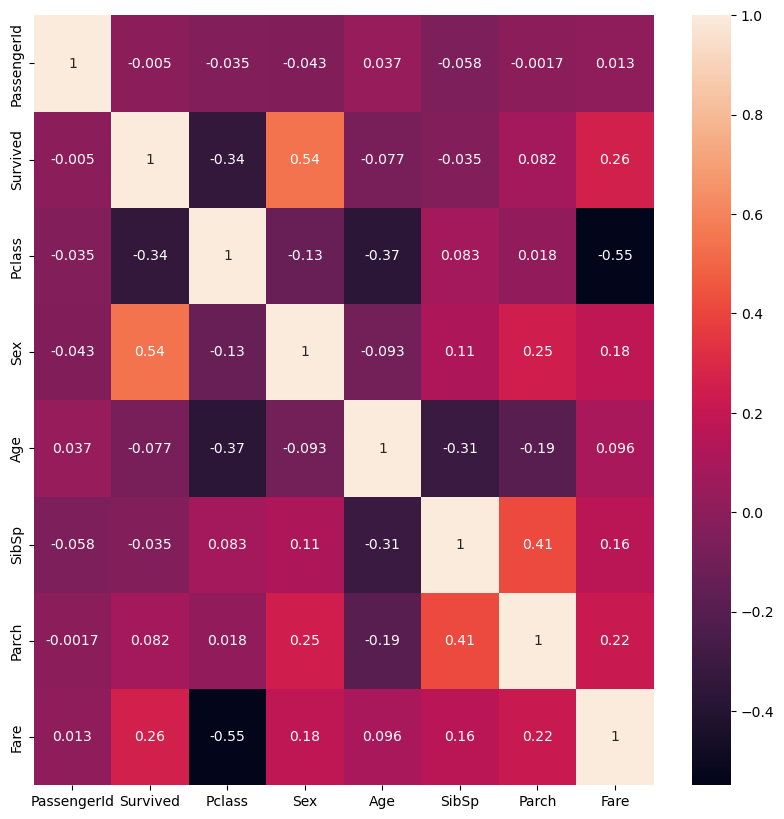

In [165]:
fig, ax = plt.subplots(figsize=(10,10))
sb.heatmap(corr_matrix, annot=True)

1. **Пропуски в данных**: В датасете были пропуски в колонках Age (20%), Cabin (77%) и Embarked (2%). Cabin пришлось удалить из-за критического количества пропусков, Age заполнили медианой, Embarked — модой.

2. **Дисбаланс классов**: Выжило 342 человека (38.4%), не выжило 549 (61.6%). Таргет умеренно несбалансирован, это нужно учитывать при выборе метрик.

3. **Возрастное распределение**: Пассажиры в основном 20–40 лет. Есть дети (до 10 лет) и пожилые (до 80). Распределение близко к нормальному, но с легкой правосторонней асимметрией.

4. **Цена билета (Fare)**: Сильнейшая асимметрия и высокий эксцесс. Большинство билетов стоили <30, но есть экстремальные выбросы до 512 — это билеты 1-го класса. Логарифмирование признака будет полезно для моделей.

5. **Социальный статус**: 1-й класс — 24% пассажиров, 2-й — 21%, 3-й — 55%. Большинство ехали в 3-м классе, что отражает социальный состав пассажиров.

6. **Семейное положение**: 60% пассажиров путешествовали одни (FamilySize=1). Большие семьи (FamilySize>4) встречаются редко и имеют низкую выживаемость.

7. **Порты посадки**: 72% пассажиров сели в Саутгемптоне (S), 19% в Шербуре (C), 9% в Квинстауне (Q). Это важно, так как выживаемость по портам сильно различается.

8. **Гендерный состав**: Мужчин 64%, женщин 36%. При этом женщины выживали в 3 раза чаще мужчин.

   Гипотезы и наблюдения
### Гипотеза 1: «Женщины и дети — в первую очередь»
**Наблюдение**: Выживаемость женщин 74%, мужчин — 18%. Дети до 10 лет выживали в 55% случаев против 35% у взрослых.
**Вывод**: Правило «сначала женщины и дети» реально работало. Пол — самый сильный предиктор.

### Гипотеза 2: «Богатые спасаются первыми»
**Наблюдение*: Выживаемость 1-г
о класса — 63%, 2-го — 47%, 3-го — 24%. Средняя цена билета у выживших — 48, у погибших — 22.
**Вывод**: Социально-экономический статус (класс и цена билета) критически влиял на доступ к шлюпкам.

### Гипотеза 3 Семьи держались вместе — и это убивало
**Наблюдение**: Максимальная выживаемость у пассажиров с семьей из 2-4 человек. У больших семей (5+ человек) выживаемость падает до 0-20%. Одиночки выживали в 30% случаев.
**Вывод**: Возможно, большие семьи пытались держаться вместе и не успевали сесть в шлюпки, либо их размещали в разных частях корабля.
   